<a href="https://colab.research.google.com/github/gleo1973/tp-laboratorio-mcag-1c2026/blob/main/Laboratorio_TP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Universidad de Buenos Aires · Facultad de Ciencias Económicas  
Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones*

# **Trabajo Práctico Grupal**
Exploración, análisis y presentación de datos reales asistida por IA  

## Análisis y comparación de los equipos de la Copa Mundial de Fútbol 2026.

*Por Leonardo Gomez, Fernando Morichetti y Carla Garibotti.*

---




# **1. Introducción**

### 1.1 Contexto general

El fútbol constituye uno de los fenómenos sociales, culturales y económicos más relevantes a nivel global. La Copa Mundial de la FIFA no solo moviliza millones de espectadores y recursos financieros, sino que también funciona como un espacio de representación nacional, competencia internacional y construcción simbólica entre países con realidades económicas, políticas y demográficas muy diferentes.

En un contexto global donde el desempeño de los países suele estar fuertemente condicionado por factores estructurales, como el nivel de desarrollo económico, la infraestructura, la inversión o el tamaño poblacional, surge una pregunta particularmente interesante en el ámbito deportivo: ¿hasta qué punto esos mismos factores influyen en el rendimiento futbolístico de las selecciones nacionales?


### 1.2 Motivación del análisis

El fútbol suele presentarse como “el deporte más democrático del mundo”: once jugadores, una pelota y la posibilidad de que cualquier país pueda competir contra las grandes potencias. Sin embargo, detrás de esa narrativa romántica aparece una pregunta incómoda: ¿hasta qué punto el éxito deportivo realmente depende de los recursos económicos y estructurales de una nación?

Mientras que en áreas como la tecnología, la educación o la producción industrial las naciones más desarrolladas suelen liderar sistemáticamente los rankings internacionales, el fútbol parece presentar dinámicas menos previsibles. Selecciones pertenecientes a países relativamente pequeños han logrado competir históricamente al máximo nivel frente a potencias económicas y demográficas globales, generando un escenario atractivo para el análisis cuantitativo.

Este contraste convierte al fútbol en un laboratorio social y económico particularmente interesante. Analizar si existe una relación estadísticamente significativa entre variables como población, tamaño económico o desarrollo nacional y el rendimiento futbolístico permite explorar una tensión central entre estructura y talento: ¿el éxito deportivo es consecuencia directa de los recursos disponibles o existen factores culturales, históricos y organizacionales capaces de romper esa lógica?

La motivación de este trabajo surge precisamente de investigar esa aparente contradicción. A partir de datasets históricos de la FIFA, información demográfica y variables geográficas de distintos países, el análisis buscará determinar si las selecciones más exitosas pertenecen sistemáticamente a las naciones más desarrolladas o si el fútbol constituye una excepción parcial dentro de los fenómenos globales donde la economía suele ser determinante.

### 1.3 Pregunta de investigación:

¿Existe una relación estadísticamente significativa entre el nivel de desarrollo económico y demográfico de un país y el puntaje FIFA de su selección nacional, o el fútbol constituye uno de los pocos espacios donde la economía no determina completamente los resultados deportivos?

En caso de que dicha relación sea débil o inexistente, ¿qué países representan excepciones relevantes y qué factores podrían explicar esos casos?


### 1.4 Objetivo general

Analizar si existe una relación estadísticamente significativa entre el nivel de desarrollo económico y demográfico de los países y el rendimiento futbolístico de sus selecciones nacionales, medido a través del puntaje FIFA y otras métricas históricas asociadas al desempeño internacional.

---


# **2. Datos y metodología**



---


# **3. Análisis exploratorio de datos**

### Importacion de Librerias

En este bloque se importan las principales librerias de Python que serán utilizadas a lo largo del trabajo para el procesamiento, análisis y visualización de los datos.

Estas herramientas conforman el entorno de trabajo principal del proyecto y permiten desarrollar tanto el análisis exploratorio inicial como la aplicación de conceptos cuantitativos vistos en la materia.

In [38]:
import pandas as pd #para manejo de archivos de datos
import numpy as np #para hacer operaciones matemáticas
import matplotlib.pyplot as plt #para hacer gráficos
import seaborn as sns #para hacer gráficos

import sympy as sp
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

### Carga de datasets principales

En este bloque se importan las primeras fuentes de datos que formarán la base del análisis. Ambos datasets serán utilizados de manera complementaria para construir una estructura unificada de información sobre selecciones nacionales y países participantes.

El primer dataset contiene información histórica y estadística relacionada con selecciones nacionales participantes en torneos organizados por la FIFA. Esta base constituye la fuente principal del análisis y permitirá estudiar el rendimiento futbolístico de los distintos países a lo largo del tiempo.

El segundo dataset corresponde al listado oficial de asociaciones miembro de la FIFA y sus respectivos códigos de identificación. Esta información será utilizada como tabla auxiliar para normalizar nombres de países y facilitar la integración entre datasets provenientes de distintas fuentes.


In [39]:
# Ver fuentes en archivo /datos/fuentes.md

df_paises = pd.read_csv("datos/raw/paises.csv")
df_cod_paises = pd.read_csv("datos/raw/fifa-member-associations.csv")

### Exploracion inicial

Consultamos la dimensión del dataset, con el objetivo de conocer la cantidad de filas y columnas disponibles en la base de datos. La cantidad de filas debe  contener 48 filas, correspondientes a los 48 equipos

In [40]:
df_paises.shape

(48, 24)

Consultamos las columnas presentes en el dataset con el objetivo de identificar las variables disponibles para el análisis.

In [41]:
df_paises.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

Visualizamos las primeras filas. Como tiene muchas columnas, vamos a transponer la tabla con el objetivo de facilitar la lectura de los campos y sus respectivos valores.

In [42]:
df_paises.head(8).T

,0,1,2,3,4,5,6,7
version,2026,2026,2026,2026,2026,2026,2026,2026
team,France,Spain,Argentina,England,Portugal,Brazil,Netherlands,Morocco
continent,Europe,Europe,South America,Europe,Europe,South America,Europe,Africa
is_host,0,0,0,0,0,0,0,0
goals_scored_last_4y,85,104,80,82,98,58,92,100
goals_received_last_4y,32,32,14,23,31,39,41,18
wins_last_4y,25,29,30,26,26,15,21,37
losses_last_4y,6,2,4,6,5,10,8,2
draws_last_4y,7,8,3,7,7,10,9,9
world_cup_titles_before,2,1,3,1,0,5,0,0


Vemos que la tabla tiene distintos valores:  
- version: refiere a la versión del torneo FIFA sobre el cuál trata la información.  
- team: identifica al equipo/plantel nacional.  
- continent: de qué continente es el equipo.  
- is_host: si es el anfitrión del torneo en el año indicado en "version".  
  
Y luego hay datos históricos sobre el desempeño de cada plantel:  
- goals_scored_last_4y: goles marcados en los últimos 4 años.  
- goals_received_last_4y: goles recibimos en los últimos 4 años.  
- wins_last_4y: victorias en los últimos 4 años.  
- losses_last_4y: pérdidas en los últimos 4 años.  
- draws_last_4y: empates en los últimos 4 años.  
- world_cup_titles_before: veces que el plantel ha ganado el torneo.  
- squad_total_market_value_eur: valor de mercado del equipo en euros.  
- fifa_rank_pre_tournament: posición en el ranking FIFA antes del comienzo del torneo.  
- fifa_points_pre_tournament: puntaje FIFA antes del comienzo del torneo.  
- squad_avg_age: edad promedio de los jugadores.  
- world_cup_participations_before: cuántas veces ha participado en la copa del Mundo.  
- groups_passed_before: cuántas veces ha superado la fase de grupos históricamente.  
- round16_before: cuántas veces ha llegado al top 16 históricamente.  
- quarterfinals_before: cuántos cuartos de finales ha jugado el plantel históricamente.  
- semifinals_before: cuántas semifinales ha jugado el plantel históricamente.  
- finals_before: cuántas finales ha jugado el plantel históricamente.  

Finalmente hay 4 columnas que se completarían luego de finalizado el torneo:  
- winner: si fue el ganador del torneo.  
- finalist: si fue finalista en el torneo.  
- semi_finalist: si fue semifinalista en el torneo.  
- quarter_finalist: si llegó a cuartos de finales en el torneo.  

Contamos los valores vacíos de la tabla.

In [43]:
df_paises.isna().sum()

version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
dtype: int64

Como las últimas cuatro columnas son para completar luego del torneo, es esperable que estén vacías.  
Revisamos el listado de países. Hay países que son nombrados de formas distintas en distintas bases de datos y como usaremos esta columna para combinar las tablas más adelante, necesitamos saber cómo están escritos.

In [44]:
df_paises["team"].unique()

array(['France', 'Spain', 'Argentina', 'England', 'Portugal', 'Brazil',
       'Netherlands', 'Morocco', 'Belgium', 'Germany', 'Croatia',
       'Colombia', 'Senegal', 'Mexico', 'United States', 'Uruguay',
       'Japan', 'Switzerland', 'Iran', 'Turkey', 'Ecuador', 'Austria',
       'South Korea', 'Australia', 'Algeria', 'Egypt', 'Canada', 'Norway',
       'Panama', 'Ivory Coast', 'Sweden', 'Paraguay', 'Czech Republic',
       'Scotland', 'Tunisia', 'DR Congo', 'Uzbekistan', 'Qatar', 'Iraq',
       'South Africa', 'Saudi Arabia', 'Jordan', 'Bosnia and Herzegovina',
       'Cape Verde', 'Ghana', 'Cura?o', 'Haiti', 'New Zealand'],
      dtype=object)

Vemos que un valor (Curaçao) quedó mal escrito, así que vamos a corregir ese valor puntual y luego vamos a revisar que ya no queden valores con "?".

In [45]:
df_paises['team'] = df_paises['team'].replace('Cura?o', 'Curaçao')
df_paises[df_paises['team'].str.contains(r'\?', na=False)]

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist


Consultamos las columnas presentes en el dataset con el objetivo de identificar las variables disponibles para el análisis.

In [46]:
df_cod_paises.columns

Index(['Country.Iso3166.Alpha2Code', 'Country.Name',
       'Subdivision.Iso3166.Code', 'FIFA.Code', 'FIFA.MemberAssociation',
       'FIFA.Joined', 'Established', 'ContinentalConfederation.Code',
       'ContinentalConfederation.Name'],
      dtype='object')

Generamos un nuevo Dataset con el merge de todas las filas de df_paises con la información de df_cod_paises haciendo el join por los campos team = Country.Name

In [47]:
# Merge para traer el código FIFA
df_paises_merge = df_paises.merge(
    df_cod_paises,
    left_on='team',
    right_on='Country.Name',
    how='left'
)


In [48]:
df_paises_merge.head()

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,quarter_finalist,Country.Iso3166.Alpha2Code,Country.Name,Subdivision.Iso3166.Code,FIFA.Code,FIFA.MemberAssociation,FIFA.Joined,Established,ContinentalConfederation.Code,ContinentalConfederation.Name
0,2026,France,Europe,0,85,32,25,6,7,2,...,NaN,FR,France,NaN,FRA,Fédération Française de Football (FFF),1904.0,1919.0,UEFA,Union of European Football Associations (UEFA)
1,2026,Spain,Europe,0,104,32,29,2,8,1,...,NaN,ES,Spain,NaN,ESP,Real Federación Española de Fútbol (FEF),1904.0,1913.0,UEFA,Union of European Football Associations (UEFA)
2,2026,Argentina,South America,0,80,14,30,4,3,3,...,NaN,AR,Argentina,NaN,ARG,Asociación del Fútbol Argentino (AFA),1912.0,1893.0,CONMEBOL,Confederação Sul-Americana de Futebol (CONMEBOL)
3,2026,England,Europe,0,82,23,26,6,7,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,...,NaN,PT,Portugal,NaN,POR,Federação Portuguesa de Futebol (FPF),1923.0,1914.0,UEFA,Union of European Football Associations (UEFA)


Se identifican los equipos/países que no obtuvieron coincidencia durante el `merge` con la tabla de códigos FIFA.  
Esto permite detectar registros sin correspondencia o discrepancias de escritura.

In [49]:
sin_codigo = df_paises_merge[df_paises_merge['FIFA.Code'].isna()][['team']]
print("Sin código FIFA:", sin_codigo)

Sin código FIFA:               team
3          England
6      Netherlands
14   United States
18            Iran
19          Turkey
22     South Korea
29     Ivory Coast
32  Czech Republic
33        Scotland
35        DR Congo
43      Cape Verde


Obtengo nombres únicos de países, para poder corregir las inconsistencias

In [50]:
# Busco la lista de paises en esta tabla para poder corregirlos con un diccionario
df_cod_paises["Country.Name"].unique()

array(['Andorra', 'United Arab Emirates (the)', 'Afghanistan',
       'Antigua and Barbuda', 'Anguilla', 'Albania', 'Armenia', 'Angola',
       'Argentina', 'American Samoa', 'Austria', 'Australia', 'Aruba',
       'Azerbaijan', 'Bosnia and Herzegovina', 'Barbados', 'Bangladesh',
       'Belgium', 'Burkina Faso', 'Bulgaria', 'Bahrain', 'Burundi',
       'Benin', 'Bermuda', 'Brunei Darussalam',
       'Bolivia (Plurinational State of)', 'Brazil', 'Bahamas (the)',
       'Bhutan', 'Botswana', 'Belarus', 'Belize', 'Canada',
       'Congo (the Democratic Republic of the)',
       'Central African Republic (the)', 'Congo (the)', 'Switzerland',
       "Côte d'Ivoire", 'Cook Islands (the)', 'Chile', 'Cameroon',
       'China', 'Colombia', 'Costa Rica', 'Cuba', 'Cabo Verde', 'Curaçao',
       'Cyprus', 'Czechia', 'Germany', 'Djibouti', 'Denmark', 'Dominica',
       'Dominican Republic (the)', 'Algeria', 'Ecuador', 'Estonia',
       'Egypt', 'Eritrea', 'Spain', 'Ethiopia', 'Finland', 'Fiji',
  

Copiamos los países que no se cruzaron y genero el diccionario para renombrarlos en la tabla de códigos.

In [51]:

country_name_dict = {
    "Iran (Islamic Republic of)" : "Iran",
    "Netherlands (Kingdom of the)" : "Netherlands",
    "United States of America (the)" : "United States",
    "Türkiye" : "Turkey",
    'Korea (the Republic of)' : "South Korea",
    "Côte d'Ivoire" : "Ivory Coast",
    'Czechia' : "Czech Republic",
    'Congo (the)' : "DR Congo",
    'Cabo Verde' : "Cape Verde"
}
df_cod_paises.replace({"Country.Name": country_name_dict},inplace=True)

In [52]:
# Reviso que haya cambiado los valores
df_cod_paises["Country.Name"].unique()

array(['Andorra', 'United Arab Emirates (the)', 'Afghanistan',
       'Antigua and Barbuda', 'Anguilla', 'Albania', 'Armenia', 'Angola',
       'Argentina', 'American Samoa', 'Austria', 'Australia', 'Aruba',
       'Azerbaijan', 'Bosnia and Herzegovina', 'Barbados', 'Bangladesh',
       'Belgium', 'Burkina Faso', 'Bulgaria', 'Bahrain', 'Burundi',
       'Benin', 'Bermuda', 'Brunei Darussalam',
       'Bolivia (Plurinational State of)', 'Brazil', 'Bahamas (the)',
       'Bhutan', 'Botswana', 'Belarus', 'Belize', 'Canada',
       'Congo (the Democratic Republic of the)',
       'Central African Republic (the)', 'DR Congo', 'Switzerland',
       'Ivory Coast', 'Cook Islands (the)', 'Chile', 'Cameroon', 'China',
       'Colombia', 'Costa Rica', 'Cuba', 'Cape Verde', 'Curaçao',
       'Cyprus', 'Czech Republic', 'Germany', 'Djibouti', 'Denmark',
       'Dominica', 'Dominican Republic (the)', 'Algeria', 'Ecuador',
       'Estonia', 'Egypt', 'Eritrea', 'Spain', 'Ethiopia', 'Finland',
       '

In [53]:
# Merge para traer el código FIFA
df_paises_merge2 = df_paises.merge(
    df_cod_paises,
    left_on='team',
    right_on='Country.Name',
    how='left'
)

In [54]:
df_paises_merge2.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist', 'Country.Iso3166.Alpha2Code', 'Country.Name',
       'Subdivision.Iso3166.Code', 'FIFA.Code', 'FIFA.MemberAssociation',
       'FIFA.Joined', 'Established', 'ContinentalConfederation.Code',
       'ContinentalConfederation.Name'],
      dtype='object')

In [55]:
# Verificar que no quedaron equipos sin código
sin_codigo = df_paises_merge2[df_paises_merge2['FIFA.Code'].isna()][['team']]
print("Sin código FIFA:", sin_codigo)

Sin código FIFA:         team
3    England
33  Scotland


In [56]:
# Completamos los códigos de los equipos que no se cruzaron porque son del Reino Unido, que compiten por separado pero tienen el mismo código ISO3166-2
# A los fines del análisis, vamos a asignarles el mismo código ISO3166-2, pero cada uno tendrá su propio código FIFA.

df_paises_merge2.loc[df_paises_merge2["team"] == "England", "FIFA.Code"] = "ENG"
df_paises_merge2.loc[df_paises_merge2["team"] == "England", "Country.Iso3166.Alpha2Code"] = "GB"
df_paises_merge2.loc[df_paises_merge2["team"] == "Scotland", "FIFA.Code"] = "SCO"
df_paises_merge2.loc[df_paises_merge2["team"] == "Scotland", "Country.Iso3166.Alpha2Code"] = "GB"

In [57]:
# Verificar que no quedaron equipos sin código
sin_codigo = df_paises_merge2[df_paises_merge2['FIFA.Code'].isna()][['team']]
print("Sin código FIFA:", sin_codigo)

Sin código FIFA: Empty DataFrame
Columns: [team]
Index: []


Sumo datos estadísticos (poblacionaes y demográficos) con otra base de datos.

In [58]:
# Fuente: https://simplemaps.com/data/countries


df_info_paises = pd.read_csv("datos/raw/country_info.csv")

Revisamos cuántas filas y columnas tiene. Debería tener más de 250 filas, ya que contiene información sobre todos los países del mundo.

In [59]:
df_info_paises.shape

(253, 18)

Revisamos qué tipo de información tiene esta tabla:

In [60]:
df_info_paises.head(3).T

,0,1,2
country,China,India,United States
demonym,Chinese,Indian,American
id,CN,IN,US
iso2,CN,IN,US
tld,.cn,.in,.us
currency,Chinese Yuan,Indian Rupee,United States Dollar
population,1413142846.0,1399179585.0,339665118.0
density,147.2,425.6,34.5
area,9596960.0,3287263.0,9833517.0
gdp,17963170.0,3465541.0,25744100.0


Vemos que la tabla cuenta con la siguiente información:
- country: nombre del país.  
- demonym: gentilicio.  
- id: código del país.  
- iso2: código ISO3166-2 (de 2 letras) que identifica cada país.
- tld: código de sitios web del país.  
- currency: moneda oficial.  
- population: población.  
- density: densidad poblacional.  
- area: extensión geográfica del país.  
- gdp: producto bruto interno (PBI).  
- median_age: mediana de edad.  
- language: idioma oficial.  
- website: web oficial.  
- calling_code: código telefónico del país.  
- driving_side: dirección de manejo vehicular.  
- continent: continente.  
- un_member: si es miembro de la ONU.  
- religion: religión principal.  

Revisamos si cuenta con valores vacíos.

In [61]:
df_info_paises.isna().sum()

country          0
demonym          9
id               1
iso2             4
tld              7
currency         8
population      14
density         16
area            11
gdp             47
median_age      28
language         8
website         13
calling_code    15
driving_side     1
continent        3
un_member        0
religion         6
dtype: int64

Vemos que tiene valores vacíos. No nos preocupa *a priori* porque no es nuestra base principal, solo necesitamos que en el cruce con la base de equipos no queden lugares vacíos, pero nos da la pauta de que tenemos que tener cuidado cuando hagamos el cruce.

Hago un merge con los códigos ISO3166 (de 2 letras) para traer la información estadística.  
**Observación**: Tanto Escocia como Inglaterra tendrán ambos la información de Reino Unido entero en las columnas que agregaremos más adelante.  
Tendremos que eliminar duplicados cuando sumemos información numérica.  

In [62]:
df_paises_merge3 = df_paises_merge2.merge(
    df_info_paises,
    left_on='Country.Iso3166.Alpha2Code',
    right_on='iso2',
    how='left'
)

Revisamos si quedaron valores vacíos.

In [63]:
df_paises_merge3.isna().sum()

version                             0
team                                0
continent_x                         0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
Country.Iso3166.Alpha2Code          0
Country.Name                        2
Subdivision.

Vemos que quedó un país sin información de PBI. Revisamos cuál.

In [64]:
sin_PBI = df_paises_merge3[df_paises_merge3['gdp'].isna()][['team']]
print(sin_PBI)

       team
45  Curaçao


Completamos este valor de forma puntual entrando a https://data.worldbank.org/indicator/NY.GDP.MKTP.CD y buscando el valor de Curaçao.

In [65]:
df_paises_merge3.loc[df_paises_merge3["team"] == "Curaçao", "gdp"] = 3561.0

Revisamos que el valor haya quedado guardado correctamente.

In [66]:
sin_PBI = df_paises_merge3[df_paises_merge3['gdp'].isna()][['team']]
print(sin_PBI)

Empty DataFrame
Columns: [team]
Index: []


Teniendo ya toda la información que nos interesa, filtramos para que nos queden las columnas que nos interesan para el análisis.

In [67]:
df_paises_f = df_paises_merge3[[
    "fifa_rank_pre_tournament", 
     "team", 
     "continent_x", 
     "squad_total_market_value_eur", 
     "fifa_points_pre_tournament", 
     "squad_avg_age",
     "population", 
     "density",
     "area", 
     "gdp", 
     "median_age", 
     "language", 
     "religion"]].copy()


Armamos un diccionario para renombrar las columnas

In [68]:

columnas = {"fifa_rank_pre_tournament":"ranking_FIFA",
            "team":"pais",
            "continent_x":"continente",
            "squad_total_market_value_eur":"valor_en_euros",
            "fifa_points_pre_tournament":"puntos_FIFA",
            "squad_avg_age":"edad_promedio_equipo",
            "population" : "poblacion",
            "density" : "densidad",
            "area" : "superficie",
            "gdp" : "pbi",
            "median_age" : "edad_mediana_pais",
            "language" : "idioma",
            }
df_paises_f.rename(columns=columnas,inplace=True)

Generamos una columna de PBI per cápita dividiendo los valores de PBI por la población.

In [69]:
df_paises_f["pbi_per_capita"] = df_paises_f["pbi"] / df_paises_f["poblacion"]

Vamos a buscar si hay relación en términos matemáticos entre las variables numéricas. A esos fines, primero revisamos los tipos de variables que tenemos.

In [70]:
df_paises_f.dtypes

ranking_FIFA              int64
pais                     object
continente               object
valor_en_euros            int64
puntos_FIFA             float64
edad_promedio_equipo    float64
poblacion               float64
densidad                float64
superficie              float64
pbi                     float64
edad_mediana_pais       float64
idioma                   object
religion                 object
pbi_per_capita          float64
dtype: object

Creamos un mapa de calor para visualizar la correlación entre las variables.  
Selecionamos solo las columnas con variables numéricas de interés. Excluyo el ranking porque es un número pero no es una variable que me interesa para el análisis de correlación).  

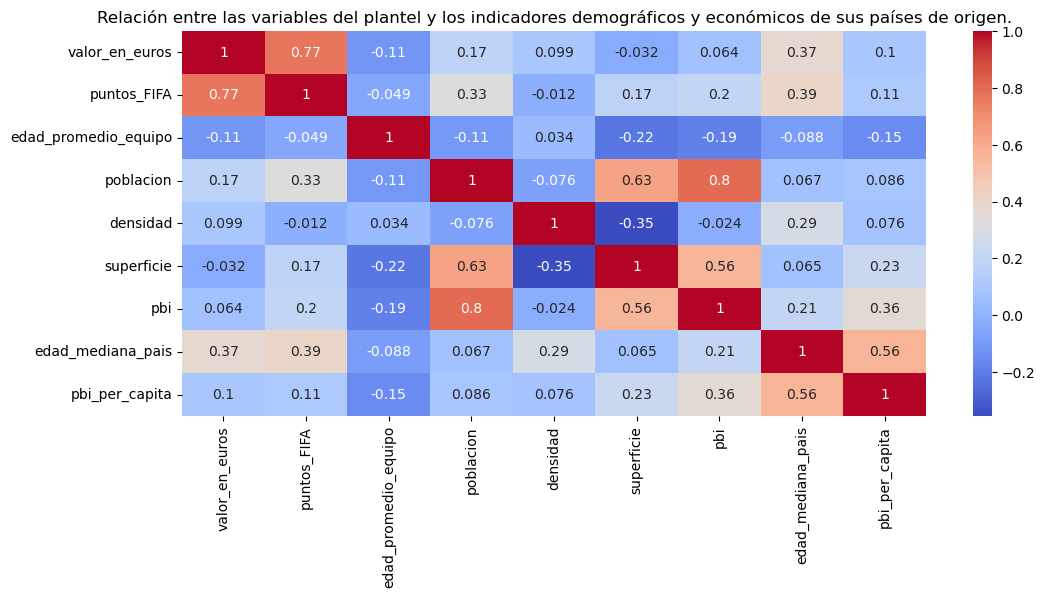

<Figure size 640x480 with 0 Axes>

In [73]:
numerico_df = df_paises_f.select_dtypes(include=[np.number]).drop(columns=["ranking_FIFA"])

plt.figure(figsize=(12, 5))
sns.heatmap(numerico_df.corr(), annot=True, cmap='coolwarm')
plt.title("Relación entre las variables del plantel y los indicadores demográficos y económicos de sus países de origen.")
plt.show()
plt.savefig("imagenes/heatmap-relacion-variables-numericas.png")


Conclusión: Hay una correlación fuerte entre el puntaje FIFA y el valor estimado del equipo, lo cual es lógico.  
Estos valores, sin embargo, no tienen ninguna correlación con los estadísticos del país que consideramos.  
Vamos a hacer entonces un scatterplot para ver qué relación tienen estas dos variables.  


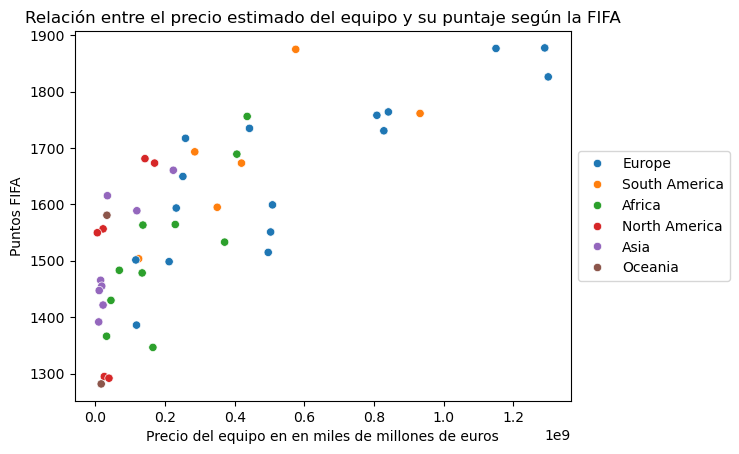

In [74]:
sns.scatterplot(
    data=df_paises_f, 
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue='continente', #el color lo da el continente
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA")
plt.xlabel('Precio del equipo en en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.savefig("imagenes/scattermap-puntajefifa-precioestimado.png")

Vemos que hay un equipo que parece lejano a la curva, aislamos los primeros 6 equipos para ver de qué país se trata:

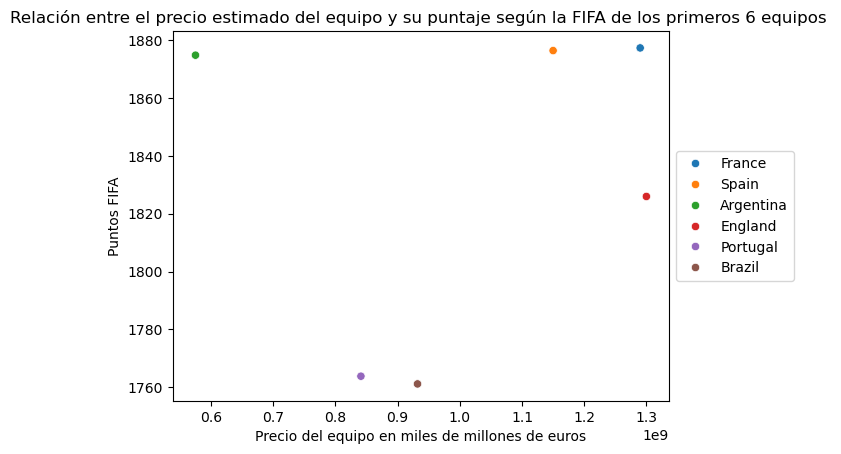

In [75]:
sns.scatterplot(
    data=df_paises_f.head(6), #detalle de los primeros 6 paises
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue="pais", #el color lo da el pais
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA de los primeros 6 equipos ")
plt.xlabel('Precio del equipo en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.savefig("imagenes/scattermap-puntajefifa-precioestimado-primeros6.png")

Conclusión: El país que parecía excepcional, por tener un precio de mercado muy inferior a lo que su puntaje indica es Argentina.  
Esto indica que Argentina tiene un desempeño mucho mejor que lo que se esperaría por el valor de sus jugadores. Múltiples motivos podrían explicar esta excepcionalidad: por ejemplo, un gran desempeño del equipo técnico, generando un equipo con sinergias que superan el valor agregado de sus jugadores.  

# Análisis por categorías
## Por continente:
Para ver si el continente de origen afecta el desempeño, generamos un boxplot que muestre la distribución de puntos FIFA por continente.

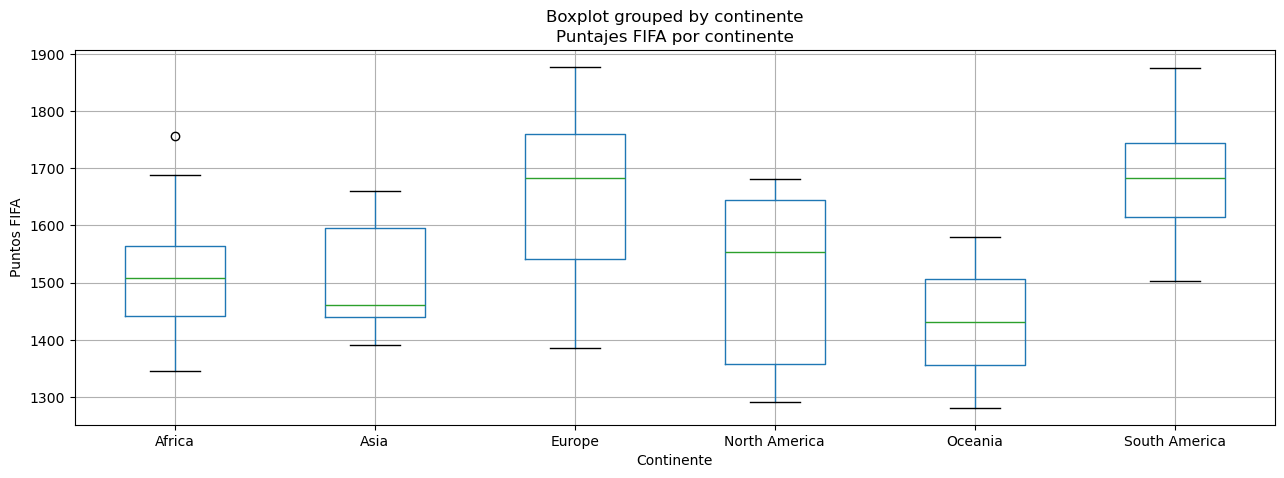

<Figure size 640x480 with 0 Axes>

In [76]:
df_paises_f.boxplot('puntos_FIFA', 'continente', figsize=(15, 5), grid=True)
plt.title("Puntajes FIFA por continente")
plt.xlabel("Continente")
plt.ylabel("Puntos FIFA")
plt.show()
plt.savefig("imagenes/boxplot-puntajefifa-continente.png")


Conclusión: El continente de origen del país sí parece ser un indicador importante del puntaje del equipo. América del Sur y Europa tienen puntajes superiores. Posibles explicaciones: la competencia intra continental obliga a subir el nivel.

## Religión
Revisamos primero cómo están distribuidas las religiones con un gráfico de torta.

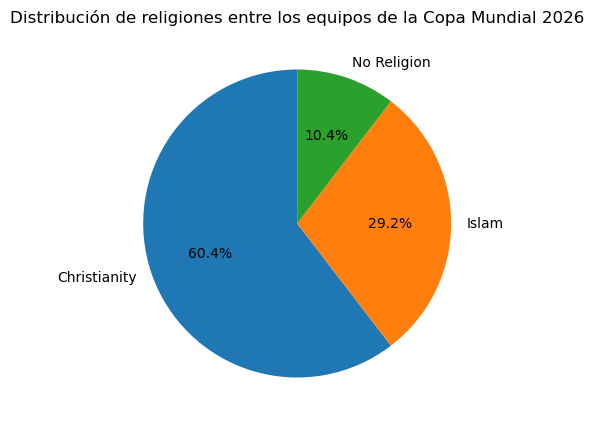

<Figure size 640x480 with 0 Axes>

In [77]:
religion_count = df_paises_f["religion"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    religion_count,
    labels=religion_count.index,   
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Distribución de religiones entre los equipos de la Copa Mundial 2026")
plt.show()
plt.savefig("imagenes/piechart-religiones.png")

Conclusión: Curiosamente, los países que participan del torneo son mayoritariamente cristianos, islámicos o no tienen religión principal. No hay países identificados como mayoritariamente budistas, hindúes o judíos.

Hacemos un boxplot para comparar los rendimientos de las distintas religiones. 

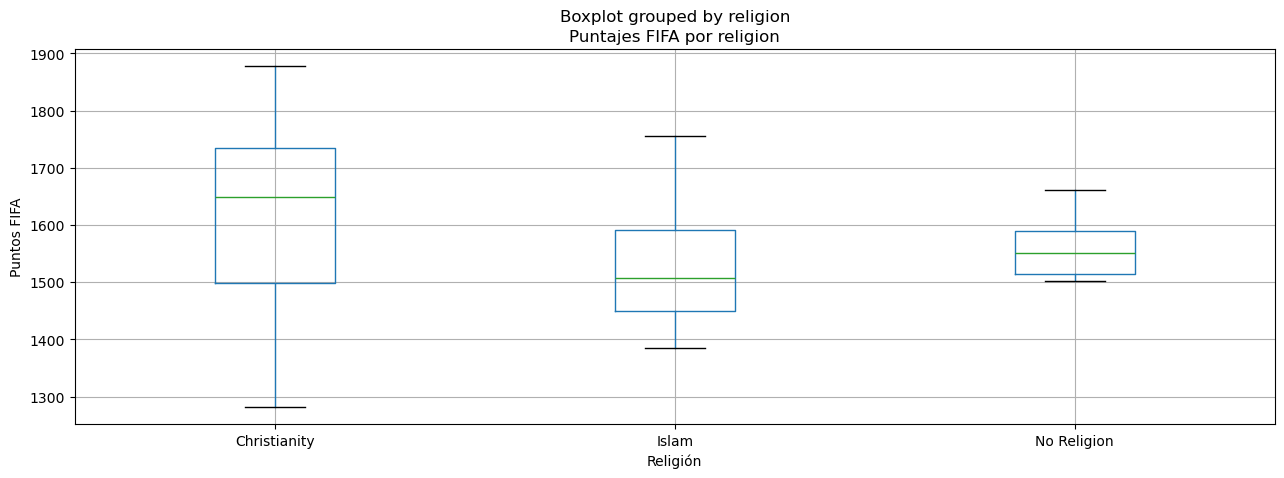

<Figure size 640x480 with 0 Axes>

In [78]:
df_paises_f.boxplot('puntos_FIFA', 'religion', figsize=(15, 5), grid=True, )
plt.title("Puntajes FIFA por religion")
plt.xlabel("Religión")
plt.ylabel("Puntos FIFA")
plt.show()
plt.savefig("imagenes/boxplot-puntajefifa-religion.png")

Los países cristianos son mayoría, así que es esperable que tengan un spread mucho mayor. Sin embargo, se ve que la mediana de los países cristianos está más alta. Podemos pensar que seguramente esta categoría esté relacionada con la de continentes y haya una variable demográfica o cultural que explica ambas.

## Idioma
Hacemos un boxplot para ver si se ve una diferencia por idioma también.

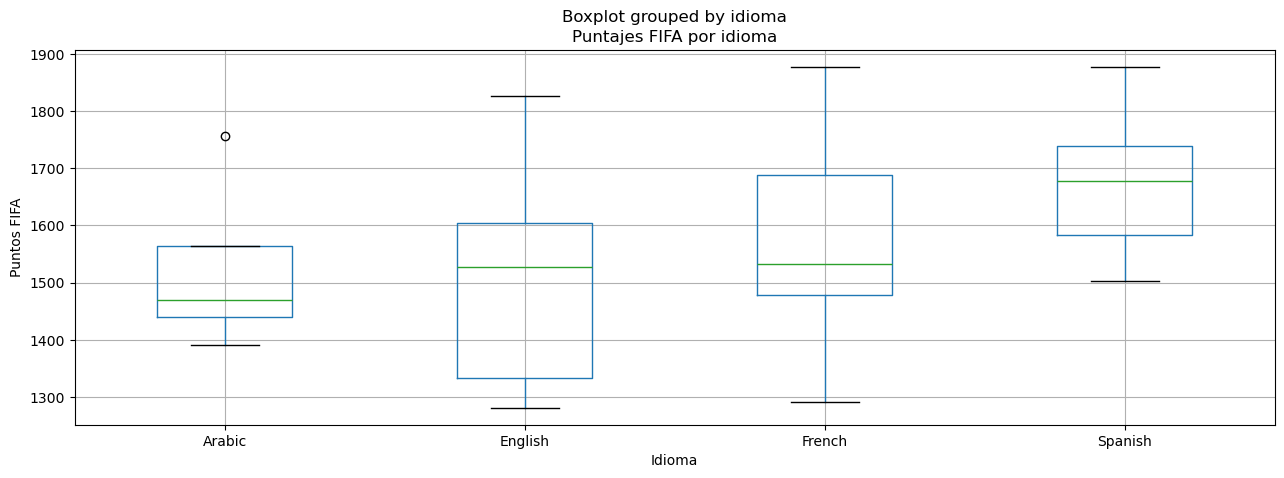

<Figure size 640x480 with 0 Axes>

In [79]:
#uso IA para filtrar y solo tomar los idiomas que tengan más de 3 paises, para que el gráfico sea legible.

df_paises_f_2 = df_paises_f.groupby('idioma').filter(lambda x: len(x) > 3)

df_paises_f_2.boxplot('puntos_FIFA', 'idioma', figsize=(15, 5), grid=True)
plt.title("Puntajes FIFA por idioma")
plt.xlabel("Idioma")
plt.ylabel("Puntos FIFA")
plt.show()
plt.savefig("imagenes/boxplot-puntajefifa-idioma.png")

# Linea entre puntos FIFA y valor del equipo
El objetivo es analizar cómo es la curva que une el puntaje FIFA y el valor estimado del equipo. Visualmente parece seguir una tendencia logarítmica (el aumento marginal va decreciendo) así que le pedí a la IA que evaluara distintos modelos para obtener la curva y luego obtener la derivada.

In [41]:
regresion_lineal = np.polyfit(df_paises_f['valor_en_euros'], df_paises_f['puntos_FIFA'], 1)

     Modelo     R²
 Cuadrático 0.6292
     Lineal 0.5902
   Potencia 0.5681
Logarítmico 0.5517

── Derivadas (tasa de cambio marginal) ──────────────────────────
  Lineal         : f'(x) = 3.48714937759280E-7
  Logarítmico    : f'(x) = 79.2172737634161/x
  Potencia       : f'(x) = 30.8629452843148/x**0.947501366280448
  Cuadrático     : f'(x) = 6.12271848140262e-7 - 4.70739736923184e-16*x

── Puntos FIFA marginales por cada €100M adicionales ────────────
  Valor (€B)          Lineal     Logarítmico        Potencia      Cuadrático
         0.1             0.0            79.2            27.3             0.0
         0.3             0.0            26.4             9.7             0.0
         0.6             0.0            13.2             5.0             0.0
         1.0             0.0             7.9             3.1             0.0
         1.4             0.0             5.7             2.2             0.0


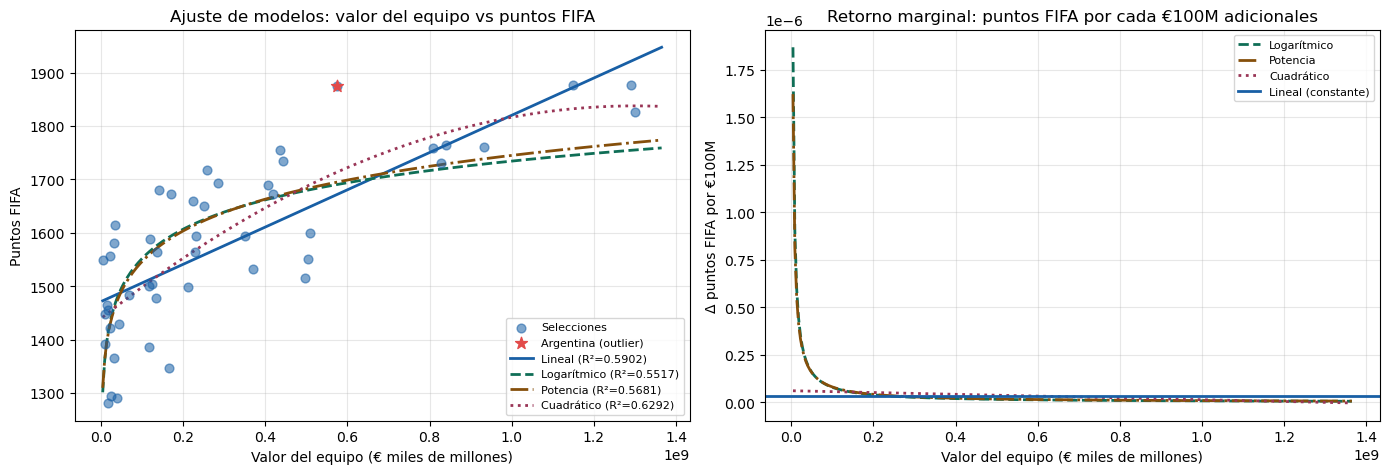

In [80]:

# ── 1. Model definitions ──────────────────────────────────────────────────────
 
def modelo_lineal(x, m, b):
    """f(x) = m·x + b"""
    return m * x + b
 
def modelo_logaritmico(x, a, b):
    """f(x) = a·ln(x) + b"""
    return a * np.log(x) + b
 
def modelo_potencia(x, a, b):
    """f(x) = a · x^b"""
    return a * np.power(x, b)
 
def modelo_cuadratico(x, a, b, c):
    """f(x) = a·x² + b·x + c"""
    return a * x**2 + b * x + c
 
# ── 2. Fit all models ─────────────────────────────────────────────────────────
 
x = df_paises_f["valor_en_euros"].values
y = df_paises_f["puntos_FIFA"].values
 
params_lin,  _ = curve_fit(modelo_lineal,      x,  y)
params_log,  _ = curve_fit(modelo_logaritmico, x,  y)
params_pow,  _ = curve_fit(modelo_potencia,    x,  y, p0=[1500, 0.3], maxfev=5000)
params_cuad, _ = curve_fit(modelo_cuadratico,  x,  y)
 
# ── 3. R² for each model ──────────────────────────────────────────────────────
 
def r_cuadrado(y_real, y_pred):
    """Coeficiente de determinación R²."""
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return 1 - ss_res / ss_tot
 
modelos = {
    "Lineal":       (modelo_lineal,      params_lin),
    "Logarítmico":  (modelo_logaritmico, params_log),
    "Potencia":     (modelo_potencia,    params_pow),
    "Cuadrático":   (modelo_cuadratico,  params_cuad),
}
 
resultados = []
for nombre, (fn, params) in modelos.items():
    y_pred = fn(x, *params)
    r2     = r_cuadrado(y, y_pred)
    resultados.append({"Modelo": nombre, "Parámetros": params, "R²": round(r2, 4)})
 
df_resultados = pd.DataFrame(resultados).sort_values("R²", ascending=False)
print(df_resultados[["Modelo", "R²"]].to_string(index=False))
 
# ── 4. Derivatives with sympy ─────────────────────────────────────────────────
 
xv = sp.Symbol("x", positive=True)
 
m_s, b_s = sp.symbols("m b", real=True)
a_s, c_s = sp.symbols("a c", real=True)
 
f_lin  = sp.Rational(*[int(round(v * 1000)) for v in [params_lin[0], 1]]) * xv / 1000 + params_lin[1]
 
# Build each function with fitted numeric coefficients
f_lin  = params_lin[0]  * xv + params_lin[1]
f_log  = params_log[0]  * sp.log(xv) + params_log[1]
f_pow  = params_pow[0]  * xv ** params_pow[1]
f_cuad = params_cuad[0] * xv**2 + params_cuad[1] * xv + params_cuad[2]
 
derivadas = {
    "Lineal":      sp.diff(f_lin,  xv),
    "Logarítmico": sp.diff(f_log,  xv),
    "Potencia":    sp.diff(f_pow,  xv),
    "Cuadrático":  sp.diff(f_cuad, xv),
}
 
print("\n── Derivadas (tasa de cambio marginal) ──────────────────────────")
for nombre, deriv in derivadas.items():
    print(f"  {nombre:15s}: f'(x) = {sp.simplify(deriv)}")
 
# ── 5. Marginal interpretation at representative values ───────────────────────
 
valores_ref = [0.1, 0.3, 0.6, 1.0, 1.4]   # €B
 
print("\n── Puntos FIFA marginales por cada €100M adicionales ────────────")
header = f"{'Valor (€B)':>12}" + "".join(f"  {k:>14}" for k in derivadas)
print(header)
for val in valores_ref:
    fila = f"{val:>12.1f}"
    for nombre, deriv in derivadas.items():
        tasa = float(deriv.subs(xv, val)) * 0.1  # per €100M
        fila += f"  {tasa:>14.1f}"
    print(fila)
 
# ── 6. Plot ───────────────────────────────────────────────────────────────────
 
x_curve = np.linspace(x.min() * 0.8, x.max() * 1.05, 300)
 
colores = {
    "Lineal":      "#185FA5",
    "Logarítmico": "#0F6E56",
    "Potencia":    "#854F0B",
    "Cuadrático":  "#993556",
}
estilos = {
    "Lineal":      "-",
    "Logarítmico": "--",
    "Potencia":    "-.",
    "Cuadrático":  ":",
}
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: scatter + all curves
ax = axes[0]
ax.scatter(x, y, color="#185FA5", alpha=0.55, s=40, zorder=3, label="Selecciones")
 
# Highlight Argentina
arg = df_paises_f[df_paises_f["pais"] == "Argentina"]
ax.scatter(arg["valor_en_euros"], arg["puntos_FIFA"],
           color="#E24B4A", s=80, zorder=4, marker="*", label="Argentina (outlier)")
 
for nombre, (fn, params) in modelos.items():
    r2 = df_resultados.loc[df_resultados["Modelo"] == nombre, "R²"].values[0]
    ax.plot(x_curve, fn(x_curve, *params),
            color=colores[nombre], ls=estilos[nombre], lw=2,
            label=f"{nombre} (R²={r2})")
 
ax.set_title("Ajuste de modelos: valor del equipo vs puntos FIFA")
ax.set_xlabel("Valor del equipo (€ miles de millones)")
ax.set_ylabel("Puntos FIFA")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)
 
# Right: marginal derivative curves (excluding linear, which is flat)
ax2 = axes[1]
for nombre, deriv in derivadas.items():
    if nombre == "Lineal":
        continue
    y_deriv = [float(deriv.subs(xv, v)) * 0.1 for v in x_curve]
    ax2.plot(x_curve, y_deriv,
             color=colores[nombre], ls=estilos[nombre], lw=2, label=nombre)
 
ax2.axhline(
    float(derivadas["Lineal"]) * 0.1,
    color=colores["Lineal"], ls="-", lw=2, label="Lineal (constante)"
)
ax2.set_title("Retorno marginal: puntos FIFA por cada €100M adicionales")
ax2.set_xlabel("Valor del equipo (€ miles de millones)")
ax2.set_ylabel("Δ puntos FIFA por €100M")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("imagenes/ajuste-modelos.png")
plt.show()

## La ecuación: f(x) = a·x² + b·x + c  
Con un ajuste cuadrático, se obtiene un coeficiente a negativo (el término x²). Este es el detalle clave. Un valor negativo de a significa que la parábola se abre hacia abajo, lo que indica que la relación entre el valor de la plantilla y los puntos FIFA tiene un límite: los puntos aumentan al invertir más, pero el crecimiento se ralentiza y, finalmente, la curva se invierte. En la práctica, existe un punto de máximo rendimiento a partir del cual invertir más dinero en la plantilla deja de mejorar la clasificación FIFA.

## La derivada: f'(x) = 2a·x + b  
A diferencia del modelo lineal, donde f'(x) era una constante, aquí la derivada es una función de x. Esto significa que el rendimiento marginal de la inversión varía según el nivel de gasto. Para los equipos con bajo gasto, cada mil millones de euros adicionales generan muchos puntos FIFA. Para los equipos con alto gasto, la misma inversión genera progresivamente menos puntos. El vértice: el número más importante
El vértice de la parábola se encuentra en x = -b/(2a). Este es el valor de la plantilla en el que se maximizan los puntos FIFA según el modelo. Se puede interpretar como el nivel de inversión "óptimo": los equipos por debajo de este valor invierten menos de lo que podrían, mientras que los que están por encima se encuentran en una situación de rendimientos decrecientes (o incluso negativos). Compruebe dónde se sitúa ese valor de x: si ronda los 0.800-1.200 millones de euros, sugiere que las selecciones europeas de élite están justo en el punto de máxima eficiencia o incluso lo han superado.

## Análisis de Argentina  
Con el modelo cuadrático, la situación atípica de Argentina resulta aún más interesante desde el punto de vista analítico. El valor de su plantilla la sitúa muy por debajo del vértice, pero sus puntos FIFA superan con creces la predicción del modelo. Esta es una anomalía concreta y cuantificable que puede destacar en el informe: el residuo de Argentina será el mayor residuo positivo del conjunto de datos, lo que significa que el modelo la subestima sistemáticamente más que a cualquier otra selección.
En cuanto al análisis del apartado 3.5, la conclusión es la siguiente: el modelo cuadrático se ajusta mejor (mayor R²), su coeficiente principal negativo confirma los rendimientos decrecientes, el vértice proporciona un umbral de inversión óptimo y el gran residuo positivo de Argentina sugiere que los factores no monetarios —calidad táctica, entrenamiento, talento generacional— pueden compensar significativamente el menor valor de mercado de la plantilla.